<a href="https://colab.research.google.com/github/02-anoop/minor/blob/main/minor_minor_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
abdallahwagih_kvasir_dataset_for_classification_and_segmentation_path = kagglehub.dataset_download('abdallahwagih/kvasir-dataset-for-classification-and-segmentation')
longvil_cvc_colondb_path = kagglehub.dataset_download('longvil/cvc-colondb')
nguyenvoquocduong_etis_laribpolypdb_path = kagglehub.dataset_download('nguyenvoquocduong/etis-laribpolypdb')

print('Data source import complete.')


# SemiDAViL: Semi-supervised Domain Adaptation with Vision-Language Guidance


## Architecture Overview
1. **CLIP Encoder** — extracts visual + text features
2. **Dense Language Guidance (DLG)** — fuses vision & language via cross-attention
3. **Segmentation Decoder** — produces pixel-wise predictions
4. **Student-Teacher Framework** — EMA-based consistency on unlabeled data
5. **DyCE Loss** — dynamic cross-entropy for class imbalance
6. **Consistency Loss** — enforces agreement on unlabeled data

In [ ]:
# install required packages
!pip install -q ftfy regex tqdm open_clip_torch albumentations

---
## Cell 2: Imports & Device Setup

In [ ]:
# all imports in one place
import os
import glob
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import open_clip
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm
from torchvision.datasets import ImageFolder
# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


---
## Cell 3: Configuration
All hyperparameters and paths in one place.

In [ ]:
TRAIN_IMG_DIR  = '/kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/images'
TRAIN_MASK_DIR = '/kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/masks'
TEST_IMG_DIR   = '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/images'
TEST_MASK_DIR  = '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/masks'


KVASIR_ROOT = '/kaggle/input/datasets/abdallahwagih/kvasir-dataset-for-classification-and-segmentation/kvasir-dataset/kvasir-dataset'


IMG_SIZE        = 352# ========================================================
# CELL 3B — Kvasir Classification Dataset
# Two classes: 0 = Normal colon, 1 = Polyp
# We manually combine folders so no disk restructuring needed
# ========================================================
import os, glob
from torch.utils.data import Dataset, ConcatDataset
from torchvision import transforms

# Folders that represent NORMAL colon tissue
NORMAL_FOLDERS = ['normal-cecum', 'normal-pylorus', 'normal-z-line']
# Folder that represents POLYP
POLYP_FOLDERS  = ['polyps']

class KvasirBinaryDataset(Dataset):
    """
    Loads Kvasir-v2 as a binary classification dataset.
    label 0 = Normal colon, label 1 = Polyp
    No folder restructuring needed — we assign labels manually.
    """
    def __init__(self, root, class_folders, label, img_size=224, augment=False):
        self.label = label
        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])
            ])

        # collect all image paths from the given folders
        self.img_paths = []
        for folder in class_folders:
            folder_path = os.path.join(root, folder)
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                self.img_paths += glob.glob(os.path.join(folder_path, ext))

        print(f"  Label {label} ({class_folders}): {len(self.img_paths)} images")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        img = self.transform(img)
        return img, self.label


print('KvasirBinaryDataset defined.')
NUM_CLASSES     = 1
CLIP_MODEL      = 'ViT-B-16'
CLIP_PRETRAINED = 'openai'


BATCH_SIZE     = 4
NUM_EPOCHS     = 10
LR             = 1e-4
WEIGHT_DECAY   = 1e-4
LABELED_RATIO  = 0.5


DYCE_HARD_PCT  = 0.2
DYCE_OMEGA     = 0.5
PSEUDO_THRESHOLD = 0.75

EMA_ALPHA = 0.999


CLASS_PROMPTS = [
    "a colonoscopy image showing a polyp",
    "an endoscopic photo of a colon polyp",
    "a photo of a polyp in the colon"
]

CLF_IMG_SIZE   = 224         # ResNet/CLIP classification input
CLF_BATCH_SIZE = 16
CLF_EPOCHS     = 20
CLF_LR         = 1e-4

print('Config loaded.')

KvasirBinaryDataset defined.
Config loaded.


In [ ]:

# CELL 3B — Kvasir Classification Dataset
# Two classes: 0 = Normal colon, 1 = Polyp

import os, glob
from torch.utils.data import Dataset, ConcatDataset
from torchvision import transforms

# Folders that represent NORMAL colon tissue
NORMAL_FOLDERS = ['normal-cecum', 'normal-pylorus', 'normal-z-line']
# Folder that represents POLYP
POLYP_FOLDERS  = ['polyps']

class KvasirBinaryDataset(Dataset):
    """
    Loads Kvasir-v2 as a binary classification dataset.
    label 0 = Normal colon, label 1 = Polyp
    No folder restructuring needed — we assign labels manually.
    """
    def __init__(self, root, class_folders, label, img_size=224, augment=False):
        self.label = label
        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])
            ])

        # collect all image paths from the given folders
        self.img_paths = []
        for folder in class_folders:
            folder_path = os.path.join(root, folder)
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                self.img_paths += glob.glob(os.path.join(folder_path, ext))

        print(f"  Label {label} ({class_folders}): {len(self.img_paths)} images")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        img = self.transform(img)
        return img, self.label


print('KvasirBinaryDataset defined.')

KvasirBinaryDataset defined.


In [ ]:

# Normal: 500 images (one folder only, to match polyp count)
# Polyp:  500 images
# Total:  1000 images → 70/15/15 split

from torch.utils.data import DataLoader, random_split, ConcatDataset

# Use only normal-cecum for Normal class so both classes = 500 images
# This gives a perfectly balanced 1:1 dataset
normal_ds = KvasirBinaryDataset(KVASIR_ROOT, ['normal-cecum'], label=0,
                                img_size=CLF_IMG_SIZE, augment=False)
polyp_ds  = KvasirBinaryDataset(KVASIR_ROOT, ['polyps'],       label=1,
                                img_size=CLF_IMG_SIZE, augment=False)

print(f'\nClass balance:')
print(f'  Normal (0) : {len(normal_ds)} images')
print(f'  Polyp  (1) : {len(polyp_ds)} images')

# Combine into one dataset
kvasir_full = ConcatDataset([normal_ds, polyp_ds])
total       = len(kvasir_full)
print(f'  Total      : {total} images')

# 70 / 15 / 15 split
n_train = int(0.70 * total)
n_val   = int(0.15 * total)
n_test  = total - n_train - n_val

clf_train_ds, clf_val_ds, clf_test_ds = random_split(
    kvasir_full, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

print(f'\nSplit — Train: {n_train} | Val: {n_val} | Test: {n_test}')

# DataLoaders
clf_train_loader = DataLoader(clf_train_ds, batch_size=CLF_BATCH_SIZE,
                              shuffle=True,  num_workers=2, drop_last=True)
clf_val_loader   = DataLoader(clf_val_ds,   batch_size=CLF_BATCH_SIZE,
                              shuffle=False, num_workers=2)
clf_test_loader  = DataLoader(clf_test_ds,  batch_size=CLF_BATCH_SIZE,
                              shuffle=False, num_workers=2)

print('DataLoaders ready.')

  Label 0 (['normal-cecum']): 500 images
  Label 1 (['polyps']): 500 images

Class balance:
  Normal (0) : 500 images
  Polyp  (1) : 500 images
  Total      : 1000 images

Split — Train: 700 | Val: 150 | Test: 150
DataLoaders ready.


---
## Cell 4: Dataset Class
Loads images + masks with augmentations for polyp segmentation.

In [ ]:
# run this to find exact folder structure
import os
for base in ['/kaggle/input/datasets/longvil/cvc-colondb', '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb']:
    print(f'\n--- {base} ---')
    for root, dirs, files in os.walk(base):
        level = root.replace(base, '').count(os.sep)
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/ ({len(files)} files)')



--- /kaggle/input/datasets/longvil/cvc-colondb ---
cvc-colondb/ (0 files)
  CVC-ColonDB/ (0 files)
    images/ (380 files)
    masks/ (380 files)

--- /kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb ---
etis-laribpolypdb/ (0 files)
  images/ (196 files)
  masks/ (196 files)


In [ ]:
class PolypDataset(Dataset):
    """Dataset for polyp segmentation."""
    def __init__(self, img_dir, mask_dir, img_size=352, augment=False):
        # collect all image paths
        self.img_paths = sorted(glob.glob(os.path.join(img_dir, '*')))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, '*')))
        self.img_size = img_size
        self.augment = augment

        # augmentation pipeline
        if augment:
            self.transform = A.Compose([
                A.Resize(img_size, img_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Resize(img_size, img_size),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # load image and mask
        img = np.array(Image.open(self.img_paths[idx]).convert('RGB'))
        mask = np.array(Image.open(self.mask_paths[idx]).convert('L'))

        # binarize mask (0 or 1)
        mask = (mask > 127).astype(np.float32)

        # apply transforms
        transformed = self.transform(image=img, mask=mask)
        img = transformed['image']          # (3, H, W)
        mask = transformed['mask']           # (H, W)
        mask = mask.unsqueeze(0).float()     # (1, H, W)

        return img, mask

print('PolypDataset class defined.')

PolypDataset class defined.


---
## Cell 5: Create DataLoaders
Splits training data into labeled + unlabeled sets.

In [ ]:
# full training dataset
full_train = PolypDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, IMG_SIZE, augment=True)

# split into labeled and unlabeled
n_total = len(full_train)
n_labeled = int(n_total * LABELED_RATIO)
n_unlabeled = n_total - n_labeled

labeled_set, unlabeled_set = torch.utils.data.random_split(
    full_train, [n_labeled, n_unlabeled],
    generator=torch.Generator().manual_seed(SEED)
)

# dataloaders
labeled_loader = DataLoader(labeled_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
unlabeled_loader = DataLoader(unlabeled_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

# test dataset
test_dataset = PolypDataset(TEST_IMG_DIR, TEST_MASK_DIR, IMG_SIZE, augment=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

print(f'Labeled: {n_labeled} | Unlabeled: {n_unlabeled} | Test: {len(test_dataset)}')

Labeled: 190 | Unlabeled: 190 | Test: 196


---
## Cell 6: Dense Language Guidance (DLG) Module
Fuses visual features with text embeddings via cross-attention (Section 3.2 of paper).

In [ ]:
class DenseLanguageGuidance(nn.Module):
    """Cross-modal fusion of vision and language features."""
    def __init__(self, embed_dim, num_heads=8):
        super().__init__()
        # project vision & text to same space
        self.vis_proj = nn.Linear(embed_dim, embed_dim)
        self.lang_proj = nn.Linear(embed_dim, embed_dim)

        # vision-to-language cross-attention
        self.v2l_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.v2l_norm = nn.LayerNorm(embed_dim)

        # language-to-vision cross-attention
        self.l2v_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.l2v_norm = nn.LayerNorm(embed_dim)

        # fusion mlp
        self.fusion_mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim)
        )
        self.out_norm = nn.LayerNorm(embed_dim)

    def forward(self, vis_tokens, lang_tokens):
        # vis_tokens: (B, N, D), lang_tokens: (B, T, D)
        v = self.vis_proj(vis_tokens)
        l = self.lang_proj(lang_tokens)

        # vision attends to language (query=vision, key/value=language)
        v2l, _ = self.v2l_attn(v, l, l)
        v2l = self.v2l_norm(v + v2l)

        # language attends to vision (query=language, key/value=vision)
        l2v, _ = self.l2v_attn(l, v, v)
        l2v = self.l2v_norm(l + l2v)

        # expand language features to match spatial dims
        l2v_expanded = l2v.mean(dim=1, keepdim=True).expand_as(v2l)

        # fuse both streams
        fused = self.fusion_mlp(torch.cat([v2l, l2v_expanded], dim=-1))
        fused = self.out_norm(vis_tokens + fused)

        return fused

print('DLG module defined.')

DLG module defined.


---
## Cell 7: Segmentation Decoder
Converts fused feature maps to pixel-wise predictions.

In [ ]:
class SegmentationDecoder(nn.Module):
    """Decodes fused features into segmentation map."""
    def __init__(self, in_channels, num_classes=1):
        super().__init__()
        self.decode = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )

    def forward(self, x, target_size):
        # x: (B, C, h, w) -> decode and upsample
        x = self.decode(x)
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        return x

print('SegmentationDecoder defined.')

SegmentationDecoder defined.


---
## Cell 8: SemiDAViL Model
Main model with CLIP backbone, DLG fusion, decoder, and student-teacher setup.

In [ ]:
class SemiDAViL(nn.Module):
    """Full SemiDAViL model for polyp segmentation."""
    def __init__(self, num_classes=1, clip_model_name='ViT-B-16', pretrained='openai'):
        super().__init__()

        # load CLIP model (frozen)
        self.clip, _, self.clip_preprocess = open_clip.create_model_and_transforms(
            clip_model_name, pretrained=pretrained
        )
        self.tokenizer = open_clip.get_tokenizer(clip_model_name)
        self.clip.eval()
        for p in self.clip.parameters():
            p.requires_grad = False

        # get feature dimension from CLIP
        self.feat_dim = self.clip.visual.output_dim      # 512 for ViT-B-16
        self.patch_size = self.clip.visual.conv1.kernel_size[0]  # 16

        # student network: DLG + decoder
        self.student_dlg = DenseLanguageGuidance(self.feat_dim)
        self.student_decoder = SegmentationDecoder(self.feat_dim, num_classes)

        # teacher network: DLG + decoder (same architecture)
        self.teacher_dlg = DenseLanguageGuidance(self.feat_dim)
        self.teacher_decoder = SegmentationDecoder(self.feat_dim, num_classes)

        # init teacher with student weights, freeze gradients
        self._init_teacher()

    def _init_teacher(self):
        """Copy student weights to teacher, disable teacher gradients."""
        for sp, tp in zip(self._student_params(), self._teacher_params()):
            tp.data.copy_(sp.data)
            tp.requires_grad = False

    def _student_params(self):
        return list(self.student_dlg.parameters()) + list(self.student_decoder.parameters())

    def _teacher_params(self):
        return list(self.teacher_dlg.parameters()) + list(self.teacher_decoder.parameters())

    def get_trainable_params(self):
        """Only student params are trained."""
        return self._student_params()

    @torch.no_grad()
    def encode_text_prompts(self, prompts, device):
        """Encode text prompts using CLIP text encoder."""
        tokens = self.tokenizer(prompts).to(device)
        text_feats = self.clip.encode_text(tokens)       # (T, D)
        text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)
        return text_feats

    @torch.no_grad()
    def extract_visual_tokens(self, images):
        """Extract patch tokens with positional embedding interpolation.
        Images arrive ImageNet-normalised (from PolypDataset).
        We undo ImageNet norm and apply CLIP's own norm before feeding
        to the frozen CLIP visual backbone.
        """
        B, _, H, W = images.shape

        # --- re-normalise: ImageNet stats → CLIP stats ---
        imagenet_mean = torch.tensor([0.485, 0.456, 0.406],
                                     device=images.device).view(1, 3, 1, 1)
        imagenet_std  = torch.tensor([0.229, 0.224, 0.225],
                                     device=images.device).view(1, 3, 1, 1)
        clip_mean     = torch.tensor([0.48145466, 0.4578275,  0.40821073],
                                     device=images.device).view(1, 3, 1, 1)
        clip_std      = torch.tensor([0.26862954, 0.26130258, 0.27577711],
                                     device=images.device).view(1, 3, 1, 1)
        images = images * imagenet_std + imagenet_mean   # undo ImageNet
        images = (images - clip_mean) / clip_std         # apply CLIP

        # patch embed via conv1
        x = self.clip.visual.conv1(images)
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)  # (B, N, D)

        # add class token
        cls_token = self.clip.visual.class_embedding.unsqueeze(0).unsqueeze(0).expand(B, -1, -1)
        x = torch.cat([cls_token, x], dim=1)             # (B, N+1, D)

        # interpolate positional embeddings to match new resolution
        pos_embed  = self.clip.visual.positional_embedding.unsqueeze(0)  # (1, 197, D)
        cls_pos    = pos_embed[:, :1, :]                 # (1, 1, D)
        patch_pos  = pos_embed[:, 1:, :]                 # (1, 196, D)

        # original grid size (14×14 for 224/16)
        orig_size  = int(patch_pos.shape[1] ** 0.5)      # 14
        new_h, new_w = H // self.patch_size, W // self.patch_size

        # reshape and interpolate to new grid size
        patch_pos = patch_pos.reshape(1, orig_size, orig_size, -1).permute(0, 3, 1, 2)
        patch_pos = F.interpolate(patch_pos, size=(new_h, new_w),
                                  mode='bicubic', align_corners=False)
        patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, new_h * new_w, -1)

        # concat cls + interpolated patch positions
        pos_embed = torch.cat([cls_pos, patch_pos], dim=1)
        x = x + pos_embed

        # pass through transformer
        x = self.clip.visual.patch_dropout(x)
        x = self.clip.visual.ln_pre(x)
        x = self.clip.visual.transformer(x)

        # remove CLS token, keep patch tokens, project
        patch_tokens = x[:, 1:, :]
        patch_tokens = patch_tokens @ self.clip.visual.proj

        return patch_tokens

    def forward(self, images, text_feats, network='student', vis_tokens=None):
        """
        vis_tokens: optionally pass pre-computed tokens to avoid
        double CLIP inference when running both student and teacher
        on the same unlabeled batch in the training loop.
        """
        B, _, H, W = images.shape

        # extract visual patch tokens (skip if already computed)
        if vis_tokens is None:
            vis_tokens = self.extract_visual_tokens(images)  # (B, N, D)

        # expand text features for batch
        lang_tokens = text_feats.unsqueeze(0).expand(B, -1, -1)  # (B, T, D)

        # select student or teacher branch
        if network == 'student':
            fused   = self.student_dlg(vis_tokens, lang_tokens)
            decoder = self.student_decoder
        else:
            with torch.no_grad():
                fused   = self.teacher_dlg(vis_tokens, lang_tokens)
            decoder = self.teacher_decoder

        # reshape to 2D feature map: (B, N, D) → (B, D, h, w)
        h, w     = H // self.patch_size, W // self.patch_size
        feat_map = fused.permute(0, 2, 1).reshape(B, self.feat_dim, h, w)

        # decode to segmentation map
        logits = decoder(feat_map, target_size=(H, W))
        return logits

print('SemiDAViL model defined.')

SemiDAViL model defined.


---
## Cell 9: DyCE Loss (Dynamic Cross-Entropy)
Focuses on hardest pixels and reweights to handle class imbalance (Section 3.4).

In [ ]:
class DyCELoss(nn.Module):
    """Dynamic Cross-Entropy loss for hard pixel mining."""
    def __init__(self, hard_pct=0.2, omega=0.5):
        super().__init__()
        self.hard_pct = hard_pct
        self.omega = omega

    def forward(self, logits, targets):
        # logits: (B, 1, H, W), targets: (B, 1, H, W)
        # compute BCE loss per pixel
        per_pixel = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        flat_loss = per_pixel.view(-1)
        flat_targets = targets.view(-1)

        if flat_loss.numel() == 0:
            return torch.tensor(0.0, device=logits.device)

        # mine top-k hardest pixels
        k = max(1, int(self.hard_pct * flat_loss.numel()))
        hard_losses, hard_idx = torch.topk(flat_loss, k)
        hard_targets = flat_targets[hard_idx]

        # class frequency in hard set
        n_pos = hard_targets.sum() + 1e-8
        n_neg = (1 - hard_targets).sum() + 1e-8
        f_H = float(k)

        # dynamic weights per pixel
        weights = torch.where(
            hard_targets > 0.5,
            1.0 / (n_pos ** (1 - self.omega)),
            1.0 / (n_neg ** (1 - self.omega))
        )

        # volume-weighted loss
        volume_w = 1.0 / (f_H ** self.omega)
        loss = volume_w * (weights * hard_losses).sum()

        return loss

print('DyCE Loss defined.')

DyCE Loss defined.


---
## Cell 10: Consistency Loss
Forces student to match teacher's high-confidence predictions on unlabeled data (Section 3.3).

In [ ]:
class ConsistencyLoss(nn.Module):
    """Student-teacher consistency on unlabeled data."""
    def __init__(self, threshold=0.95):
        super().__init__()
        self.threshold = threshold

    def forward(self, student_logits, teacher_logits):
        # teacher predictions as pseudo-labels
        teacher_probs = torch.sigmoid(teacher_logits.detach())

        # high-confidence mask (teacher is confident)
        confidence = torch.max(teacher_probs, 1 - teacher_probs)
        mask = (confidence >= self.threshold).float()

        if mask.sum() == 0:
            return torch.tensor(0.0, device=student_logits.device)

        # binary pseudo-labels from teacher
        pseudo_labels = (teacher_probs > 0.5).float()

        # BCE on confident pixels only
        per_pixel = F.binary_cross_entropy_with_logits(student_logits, pseudo_labels, reduction='none')
        masked_loss = (per_pixel * mask).sum() / mask.sum()

        return masked_loss

print('Consistency Loss defined.')

Consistency Loss defined.


---
## Cell 11: Dice + BCE Combined Loss
Additional supervised loss for better segmentation quality.

In [ ]:
class DiceBCELoss(nn.Module):
    """Dice + BCE combination for segmentation."""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        flat_p = probs.view(-1)
        flat_t = targets.view(-1)

        # dice loss
        intersection = (flat_p * flat_t).sum()
        dice = 1 - (2 * intersection + self.smooth) / (flat_p.sum() + flat_t.sum() + self.smooth)

        # bce loss
        bce = F.binary_cross_entropy_with_logits(logits, targets)

        return dice + bce

print('DiceBCE Loss defined.')

DiceBCE Loss defined.


---
## Cell 12: EMA Update for Teacher
Updates teacher weights as exponential moving average of student (Eq. 6 in paper).

In [ ]:
@torch.no_grad()
def update_teacher_ema(student_params, teacher_params, alpha=0.999):
    """θ_T = α * θ_T + (1-α) * θ_S"""
    for sp, tp in zip(student_params, teacher_params):
        tp.data.mul_(alpha).add_(sp.data, alpha=1 - alpha)

print('EMA updater defined.')

EMA updater defined.


---
## Cell 13: Evaluation Metrics
Dice Score, IoU, Precision, Recall for polyp segmentation.

In [ ]:
def compute_metrics(pred, target, threshold=0.5):
    """Compute dice, iou, precision, recall."""
    pred = (torch.sigmoid(pred) > threshold).float()
    target = target.float()

    # flatten
    p = pred.view(-1)
    t = target.view(-1)

    tp = (p * t).sum()
    fp = (p * (1 - t)).sum()
    fn = ((1 - p) * t).sum()

    # dice
    dice = (2 * tp + 1e-8) / (2 * tp + fp + fn + 1e-8)

    # iou
    iou = (tp + 1e-8) / (tp + fp + fn + 1e-8)

    # precision & recall
    precision = (tp + 1e-8) / (tp + fp + 1e-8)
    recall = (tp + 1e-8) / (tp + fn + 1e-8)

    return {
        'dice': dice.item(),
        'iou': iou.item(),
        'precision': precision.item(),
        'recall': recall.item()
    }

print('Metrics function defined.')

Metrics function defined.


---
## Cell 14: Initialize Model, Optimizer, Losses

In [ ]:
# create model
model = SemiDAViL(num_classes=NUM_CLASSES, clip_model_name=CLIP_MODEL, pretrained=CLIP_PRETRAINED).to(DEVICE)

# --- FIXED: prompt ensembling — encode 3 prompts and average ---
all_text_feats = model.encode_text_prompts(CLASS_PROMPTS, DEVICE)  # (3, 512)
text_feats     = all_text_feats.mean(dim=0, keepdim=True)          # (1, 512)
print(f'Text features shape: {text_feats.shape}')
print(f'Prompts used: {CLASS_PROMPTS}')

# optimizer (only student params)
optimizer = torch.optim.AdamW(model.get_trainable_params(), lr=LR, weight_decay=WEIGHT_DECAY)

# learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# loss functions
dyce_loss_fn        = DyCELoss(hard_pct=DYCE_HARD_PCT, omega=DYCE_OMEGA)
consistency_loss_fn = ConsistencyLoss(threshold=PSEUDO_THRESHOLD)
dicebce_loss_fn     = DiceBCELoss()

# count trainable params
n_params = sum(p.numel() for p in model.get_trainable_params())
print(f'Trainable parameters: {n_params:,}')

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Text features shape: torch.Size([1, 512])
Prompts used: ['a colonoscopy image showing a polyp', 'an endoscopic photo of a colon polyp', 'a photo of a polyp in the colon']
Trainable parameters: 4,966,785


---
## Cell 15: Training Loop
Combines supervised (DyCE + DiceBCE) and unsupervised (consistency) losses.
Teacher is updated via EMA after each step.

In [ ]:
# training history
history = {'train_loss': [], 'sup_loss': [], 'con_loss': [], 'val_dice': []}
best_dice = 0.0

for epoch in range(NUM_EPOCHS):
    model.student_dlg.train()
    model.student_decoder.train()

    epoch_loss, epoch_sup, epoch_con = 0, 0, 0
    n_batches = 0

    # create iterators
    labeled_iter   = iter(labeled_loader)
    unlabeled_iter = iter(unlabeled_loader)
    n_steps        = min(len(labeled_loader), len(unlabeled_loader))

    pbar = tqdm(range(n_steps), desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')

    for step in pbar:
        # fetch labeled batch
        try:
            imgs_l, masks_l = next(labeled_iter)
        except StopIteration:
            labeled_iter    = iter(labeled_loader)
            imgs_l, masks_l = next(labeled_iter)

        # fetch unlabeled batch
        try:
            imgs_u, _ = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            imgs_u, _      = next(unlabeled_iter)

        imgs_l, masks_l = imgs_l.to(DEVICE), masks_l.to(DEVICE)
        imgs_u          = imgs_u.to(DEVICE)

        optimizer.zero_grad()

        # --- supervised loss on labeled data ---
        student_logits_l = model(imgs_l, text_feats, network='student')
        sup_loss = (dyce_loss_fn(student_logits_l, masks_l)
                    + dicebce_loss_fn(student_logits_l, masks_l))

        # --- FIXED: compute vis_tokens ONCE, share between teacher + student ---
        with torch.no_grad():
            vis_tokens_u = model.extract_visual_tokens(imgs_u)

        teacher_logits_u = model(imgs_u, text_feats, network='teacher',
                                 vis_tokens=vis_tokens_u)
        student_logits_u = model(imgs_u, text_feats, network='student',
                                 vis_tokens=vis_tokens_u)
        con_loss = consistency_loss_fn(student_logits_u, teacher_logits_u)

        # --- FIXED: anneal consistency weight 0.1 → 0.5 over training ---
        con_weight = 0.1 + 0.4 * (epoch / max(NUM_EPOCHS - 1, 1))
        total_loss = sup_loss + con_weight * con_loss

        total_loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.get_trainable_params(), max_norm=1.0)
        optimizer.step()

        # update teacher via EMA
        update_teacher_ema(model._student_params(), model._teacher_params(), EMA_ALPHA)

        # track losses
        epoch_loss += total_loss.item()
        epoch_sup  += sup_loss.item()
        epoch_con  += con_loss.item()
        n_batches  += 1

        pbar.set_postfix(
            loss=f'{total_loss.item():.4f}',
            sup=f'{sup_loss.item():.4f}',
            con=f'{con_loss.item():.4f}',
            con_w=f'{con_weight:.2f}'
        )

    scheduler.step()

    # average losses
    avg_loss = epoch_loss / max(n_batches, 1)
    avg_sup  = epoch_sup  / max(n_batches, 1)
    avg_con  = epoch_con  / max(n_batches, 1)

    # quick validation on test set
    model.student_dlg.eval()
    model.student_decoder.eval()
    val_dices = []

    with torch.no_grad():
        for imgs_t, masks_t in test_loader:
            imgs_t, masks_t = imgs_t.to(DEVICE), masks_t.to(DEVICE)
            preds = model(imgs_t, text_feats, network='student')
            m     = compute_metrics(preds, masks_t)
            val_dices.append(m['dice'])

    val_dice = np.mean(val_dices)

    # save best model
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save({
            'epoch':         epoch,
            'student_dlg':   model.student_dlg.state_dict(),
            'student_decoder': model.student_decoder.state_dict(),
            'val_dice':      val_dice,
        }, 'best_semidavil.pth')

    history['train_loss'].append(avg_loss)
    history['sup_loss'].append(avg_sup)
    history['con_loss'].append(avg_con)
    history['val_dice'].append(val_dice)

    print(f'Epoch {epoch+1:>2}/{NUM_EPOCHS} | '
          f'Loss: {avg_loss:.4f} | Sup: {avg_sup:.4f} | '
          f'Con: {avg_con:.4f} | Val Dice: {val_dice:.4f} | '
          f'Best: {best_dice:.4f}')

print(f'\nTraining complete. Best Val Dice: {best_dice:.4f}')

Epoch 1/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch  1/10 | Loss: 2.5045 | Sup: 2.4464 | Con: 0.5810 | Val Dice: 0.1723 | Best: 0.1723


Epoch 2/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch  2/10 | Loss: 2.3281 | Sup: 2.2415 | Con: 0.5997 | Val Dice: 0.0069 | Best: 0.1723


Epoch 3/10:   0%|          | 0/47 [00:00<?, ?it/s]

...

Epoch  8/10 | Loss: 1.9528 | Sup: 1.8890 | Con: 0.1553 | Val Dice: 0.3294 | Best: 0.3294


Epoch 9/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch  9/10 | Loss: 1.9330 | Sup: 1.8710 | Con: 0.1361 | Val Dice: 0.2913 | Best: 0.3294


Epoch 10/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 10/10 | Loss: 1.8956 | Sup: 1.8375 | Con: 0.1161 | Val Dice: 0.2542 | Best: 0.3294

Training complete. Best Val Dice: 0.3294


---
## Cell 16: Training Curves
Plot loss and dice curves over epochs.

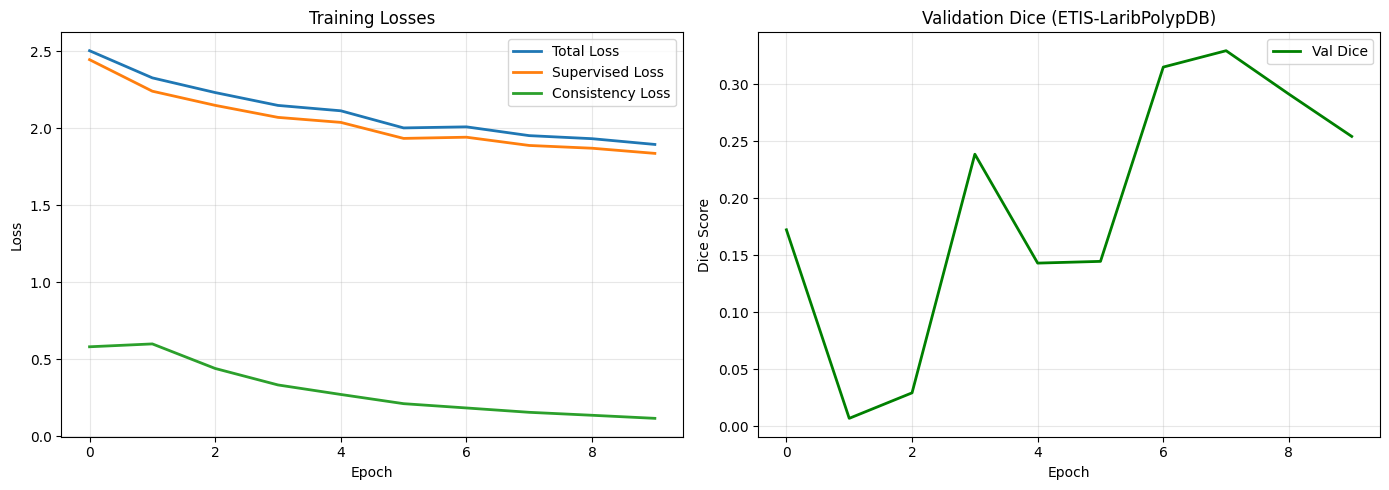

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# loss curves
ax1.plot(history['train_loss'], label='Total Loss', linewidth=2)
ax1.plot(history['sup_loss'], label='Supervised Loss', linewidth=2)
ax1.plot(history['con_loss'], label='Consistency Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Losses')
ax1.legend()
ax1.grid(True, alpha=0.3)

# dice curve
ax2.plot(history['val_dice'], label='Val Dice', color='green', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.set_title('Validation Dice (ETIS-LaribPolypDB)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

---
## Cell 17: Load Best Model & Full Evaluation
Evaluate on ETIS-LaribPolypDB test set with all metrics.

In [ ]:
# load best checkpoint
ckpt = torch.load('best_semidavil.pth', map_location=DEVICE, weights_only=False)
model.student_dlg.load_state_dict(ckpt['student_dlg'])
model.student_decoder.load_state_dict(ckpt['student_decoder'])
print(f'Loaded best model from epoch {ckpt["epoch"] + 1}')

# evaluate
model.student_dlg.eval()
model.student_decoder.eval()

all_metrics = {'dice': [], 'iou': [], 'precision': [], 'recall': []}

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Testing'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs, text_feats, network='student')
        m = compute_metrics(preds, masks)
        for k, v in m.items():
            all_metrics[k].append(v)

# print results
print('\n' + '='*50)
print('ETIS-LaribPolypDB Test Results')
print('='*50)
for k, v in all_metrics.items():
    print(f'{k:>12}: {np.mean(v):.4f} ± {np.std(v):.4f}')
print('='*50)

Loaded best model from epoch 8


Testing:   0%|          | 0/196 [00:00<?, ?it/s]


ETIS-LaribPolypDB Test Results
        dice: 0.3294 ± 0.3355
         iou: 0.2530 ± 0.2812
   precision: 0.3622 ± 0.3672
      recall: 0.4091 ± 0.4099


---
## Cell 18: Visualize Predictions
Show sample images, ground truth, and model predictions side by side.

---
## Cell 19: Overlay Predictions on Images
Overlay predicted polyp masks on original images for visual inspection.

In [ ]:
import pandas as pd

# load best checkpoint
ckpt = torch.load('best_semidavil.pth', map_location=DEVICE, weights_only=False)
model.student_dlg.load_state_dict(ckpt['student_dlg'])
model.student_decoder.load_state_dict(ckpt['student_decoder'])
print(f'Loaded best model from epoch {ckpt["epoch"] + 1}')

# evaluate
model.student_dlg.eval()
model.student_decoder.eval()
results = []

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Testing'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs, text_feats, network='student')
        m = compute_metrics(preds, masks)

        pred_bin = (torch.sigmoid(preds) > 0.5).float()
        tp = (pred_bin * masks).sum().item()
        fp = (pred_bin * (1 - masks)).sum().item()
        fn = ((1 - pred_bin) * masks).sum().item()
        tn = ((1 - pred_bin) * (1 - masks)).sum().item()

        f1       = (2 * tp) / (2 * tp + fp + fn + 1e-8)
        accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)

        results.append({
            'dice':      m['dice'],
            'iou':       m['iou'],
            'precision': m['precision'],
            'recall':    m['recall'],
            'f1':        f1,
            'accuracy':  accuracy
        })

# create dataframe
df = pd.DataFrame(results)

print('\n' + '='*50)
print('ETIS-LaribPolypDB Test Results')
print('='*50)
for col in df.columns:
    print(f'{col:>12}: {df[col].mean():.4f} ± {df[col].std():.4f}')
print('='*50)

Loaded best model from epoch 8


Testing:   0%|          | 0/196 [00:00<?, ?it/s]


ETIS-LaribPolypDB Test Results
        dice: 0.3294 ± 0.3364
         iou: 0.2530 ± 0.2819
   precision: 0.3622 ± 0.3682
      recall: 0.4091 ± 0.4110
          f1: 0.3294 ± 0.3364
    accuracy: 0.9596 ± 0.0400


In [ ]:
import pandas as pd

# also compute f1 and accuracy for each sample
results = []
model.student_dlg.eval()
model.student_decoder.eval()

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='computing metrics'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs, text_feats, network='student')
        pred_bin = (torch.sigmoid(preds) > 0.5).float()

        p = pred_bin.view(-1)
        t = masks.view(-1)
        tp = (p * t).sum().item()
        fp = (p * (1 - t)).sum().item()
        fn = ((1 - p) * t).sum().item()
        tn = ((1 - p) * (1 - t)).sum().item()

        dice = (2*tp) / (2*tp + fp + fn + 1e-8)
        iou = tp / (tp + fp + fn + 1e-8)
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = (2 * precision * recall) / (precision + recall + 1e-8)
        accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)

        results.append({
            'dice': dice, 'iou': iou, 'precision': precision,
            'recall': recall, 'f1': f1, 'accuracy': accuracy
        })

df = pd.DataFrame(results)
print(f'df created with {len(df)} samples')
print(df.describe().round(4))


computing metrics:   0%|          | 0/196 [00:00<?, ?it/s]

df created with 196 samples
           dice       iou  precision    recall        f1  accuracy
count  196.0000  196.0000   196.0000  196.0000  196.0000  196.0000
mean     0.3294    0.2530     0.3469    0.4091    0.3294    0.9596
std      0.3364    0.2819     0.3621    0.4110    0.3364    0.0400
min      0.0000    0.0000     0.0000    0.0000    0.0000    0.7657
25%      0.0000    0.0000     0.0000    0.0000    0.0000    0.9494
50%      0.2395    0.1360     0.2125    0.3320    0.2395    0.9721
75%      0.6346    0.4648     0.6797    0.8454    0.6346    0.9854
max      0.9377    0.8828     0.9990    1.0000    0.9377    0.9987


In [ ]:
# observation table with mean, std, min, max
summary = df[['dice', 'iou', 'precision', 'recall', 'f1', 'accuracy']].describe().T
summary = summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary.columns = ['Mean', 'Std', 'Min', 'Q1', 'Median', 'Q3', 'Max']
summary = summary.round(4)

print('='*70)
print('OBSERVATION TABLE: SemiDAViL on ETIS-LaribPolypDB')
print('='*70)
print(summary.to_string())
print('='*70)

# styled display
summary.style.background_gradient(cmap='Greens', subset=['Mean'])\
             .background_gradient(cmap='Reds_r', subset=['Std'])\
             .format('{:.4f}')


OBSERVATION TABLE: SemiDAViL on ETIS-LaribPolypDB
             Mean     Std     Min      Q1  Median      Q3     Max
dice       0.3294  0.3364  0.0000  0.0000  0.2395  0.6346  0.9377
iou        0.2530  0.2819  0.0000  0.0000  0.1360  0.4648  0.8828
precision  0.3469  0.3621  0.0000  0.0000  0.2125  0.6797  0.9990
recall     0.4091  0.4110  0.0000  0.0000  0.3320  0.8454  1.0000
f1         0.3294  0.3364  0.0000  0.0000  0.2395  0.6346  0.9377
accuracy   0.9596  0.0400  0.7657  0.9494  0.9721  0.9854  0.9987


,Mean,Std,Min,Q1,Median,Q3,Max
dice,0.3294,0.3364,0.0000,0.0000,0.2395,0.6346,0.9377
iou,0.2530,0.2819,0.0000,0.0000,0.1360,0.4648,0.8828
precision,0.3469,0.3621,0.0000,0.0000,0.2125,0.6797,0.9990
recall,0.4091,0.4110,0.0000,0.0000,0.3320,0.8454,1.0000
f1,0.3294,0.3364,0.0000,0.0000,0.2395,0.6346,0.9377
accuracy,0.9596,0.0400,0.7657,0.9494,0.9721,0.9854,0.9987


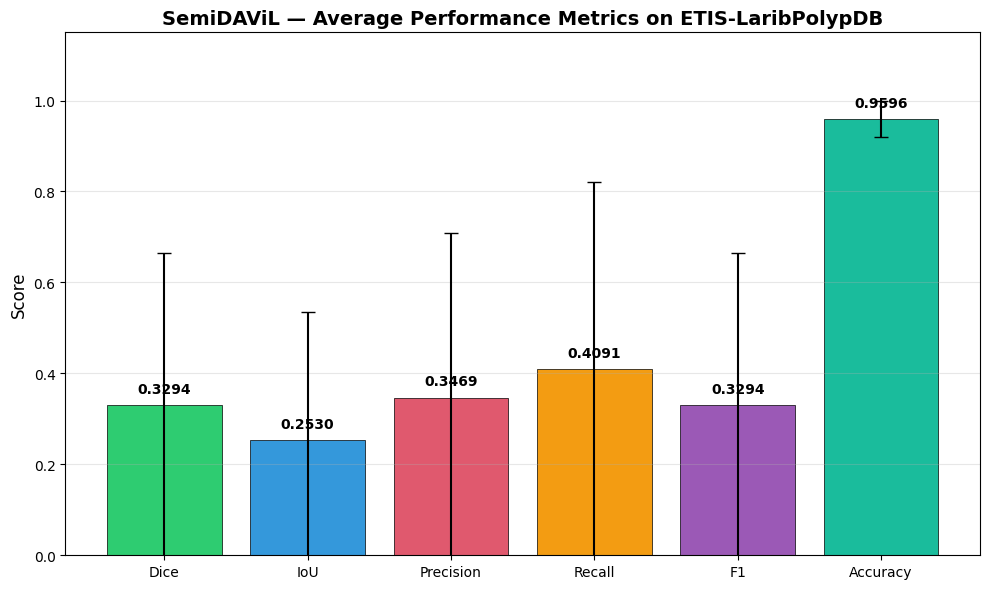

In [ ]:
# bar chart of average metrics
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Dice', 'IoU', 'Precision', 'Recall', 'F1', 'Accuracy']
values = [df['dice'].mean(), df['iou'].mean(), df['precision'].mean(),
          df['recall'].mean(), df['f1'].mean(), df['accuracy'].mean()]
errors = [df['dice'].std(), df['iou'].std(), df['precision'].std(),
          df['recall'].std(), df['f1'].std(), df['accuracy'].std()]

colors = ['#2ecc71', '#3498db', '#e0596e', '#f39c12', '#9b59b6', '#1abc9c']
bars = ax.bar(metrics, values, yerr=errors, capsize=5, color=colors,
              edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('SemiDAViL — Average Performance Metrics on ETIS-LaribPolypDB',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=150)
plt.show()


/tmp/ipykernel_58/1555260216.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df['dice'], df['iou'], df['precision'], df['recall'], df['f1'], df['accuracy']],


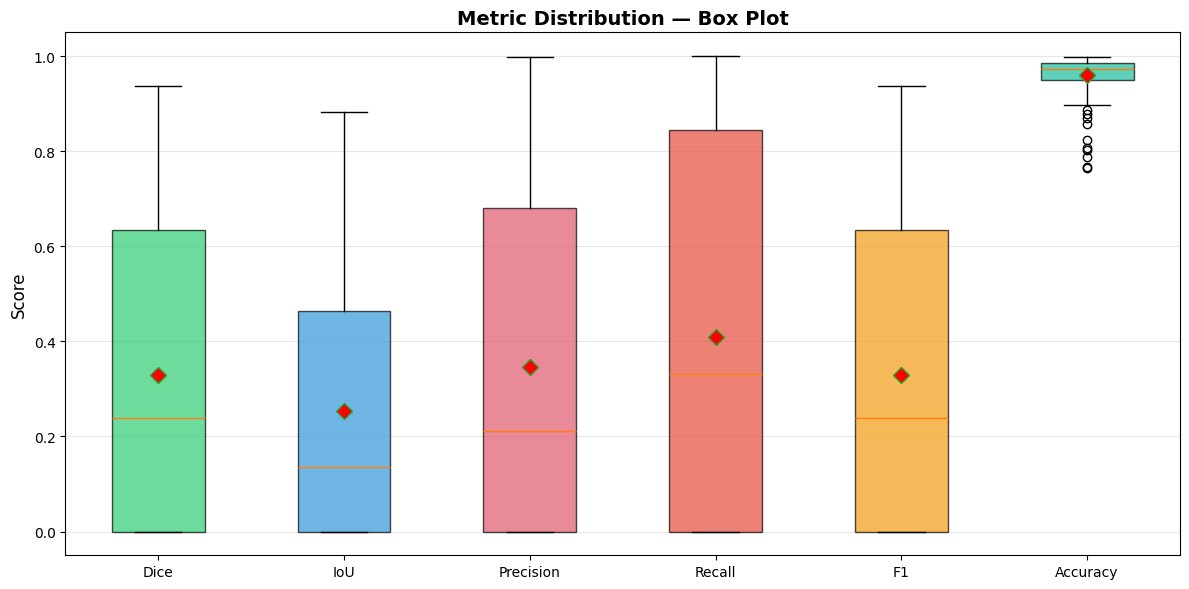

In [ ]:
# box plot of metric distributions
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot([df['dice'], df['iou'], df['precision'], df['recall'], df['f1'], df['accuracy']],
                labels=['Dice', 'IoU', 'Precision', 'Recall', 'F1', 'Accuracy'],
                patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

colors = ['#2ecc71', '#3498db', '#e0596e', '#e74c3c', '#f39c12', '#1abc9c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Metric Distribution — Box Plot', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_metrics.png', dpi=150)
plt.show()


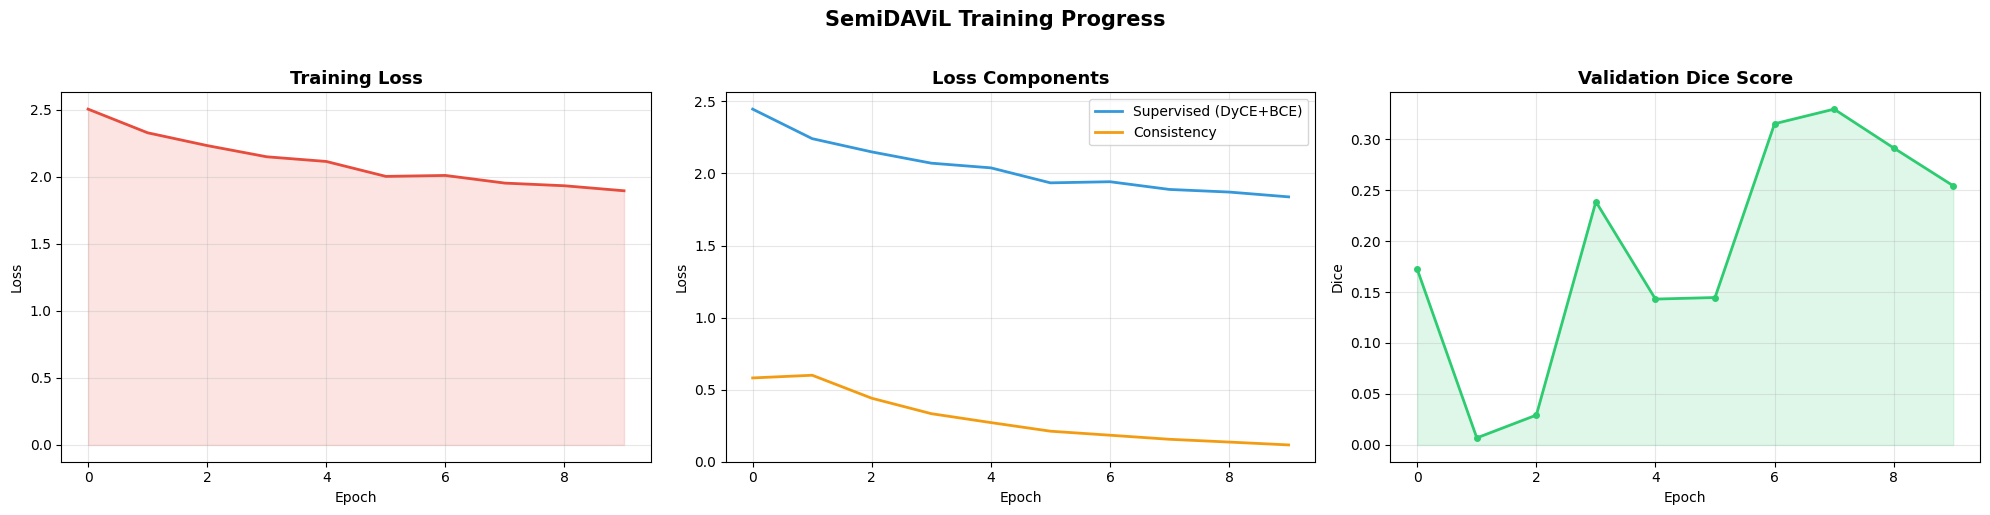

In [ ]:
# training curves
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# total loss
axes[0].plot(history['train_loss'], color='#e74c3c', linewidth=2)
axes[0].fill_between(range(len(history['train_loss'])), history['train_loss'], alpha=0.15, color='#e74c3c')
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

# supervised vs consistency loss
axes[1].plot(history['sup_loss'], label='Supervised (DyCE+BCE)', color='#3498db', linewidth=2)
axes[1].plot(history['con_loss'], label='Consistency', color='#f39c12', linewidth=2)
axes[1].set_title('Loss Components', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# validation dice
axes[2].plot(history['val_dice'], color='#2ecc71', linewidth=2, marker='o', markersize=4)
axes[2].fill_between(range(len(history['val_dice'])), history['val_dice'], alpha=0.15, color='#2ecc71')
axes[2].set_title('Validation Dice Score', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Dice')
axes[2].grid(alpha=0.3)

plt.suptitle('SemiDAViL Training Progress', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# final formatted observation table
print('\n' + '='*75)
print('FINAL OBSERVATION TABLE — SemiDAViL Polyp Segmentation')
print('='*75)
print(f'{"Metric":<15} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-'*75)

for metric in ['dice', 'iou', 'precision', 'recall', 'f1', 'accuracy']:
    s, m, mx = df[metric].std(), df[metric].min(), df[metric].max()
    mn = df[metric].mean()
    print(f'{metric.upper():<15} {mn:>8.4f} {s:>8.4f} {m:>8.4f} {mx:>8.4f}')

print('='*75)
print(f'TRAIN DATASET: CVC-ColonDB (380 images)')
print(f'TEST DATASET: ETIS-LaribPolypDB (196 images)')
print(f'MODEL: SemiDAViL (CLIP ViT-B/16 + DLG + Student-Teacher)')
print(f'EPOCHS: {NUM_EPOCHS} | BATCH SIZE: {BATCH_SIZE}')
print(f'BEST VAL DICE: {best_dice:.4f}')
print('='*75)



FINAL OBSERVATION TABLE — SemiDAViL Polyp Segmentation
Metric              Mean      Std      Min      Max
---------------------------------------------------------------------------
DICE              0.3294   0.3364   0.0000   0.9377
IOU               0.2530   0.2819   0.0000   0.8828
PRECISION         0.3469   0.3621   0.0000   0.9990
RECALL            0.4091   0.4110   0.0000   1.0000
F1                0.3294   0.3364   0.0000   0.9377
ACCURACY          0.9596   0.0400   0.7657   0.9987
TRAIN DATASET: CVC-ColonDB (380 images)
TEST DATASET: ETIS-LaribPolypDB (196 images)
MODEL: SemiDAViL (CLIP ViT-B/16 + DLG + Student-Teacher)
EPOCHS: 10 | BATCH SIZE: 4
BEST VAL DICE: 0.3294


---
## Cell 17: Bidirectional CARZero Architecture (Phase 2)
Defines the custom classification model with Bidirectional Node Attention.

---
## Cell 18: Train CARZero Classifier on Polyps
Uses the mask-to-label mathematical trick to train the classification model.

---
## Cell 19: End-to-End Polyp Pipeline
Runs Phase 1 (Segmentation) and Phase 2 (Classification) on a random ETIS image.

Segmentation test set: 196 images (ETIS-LaribPolypDB)


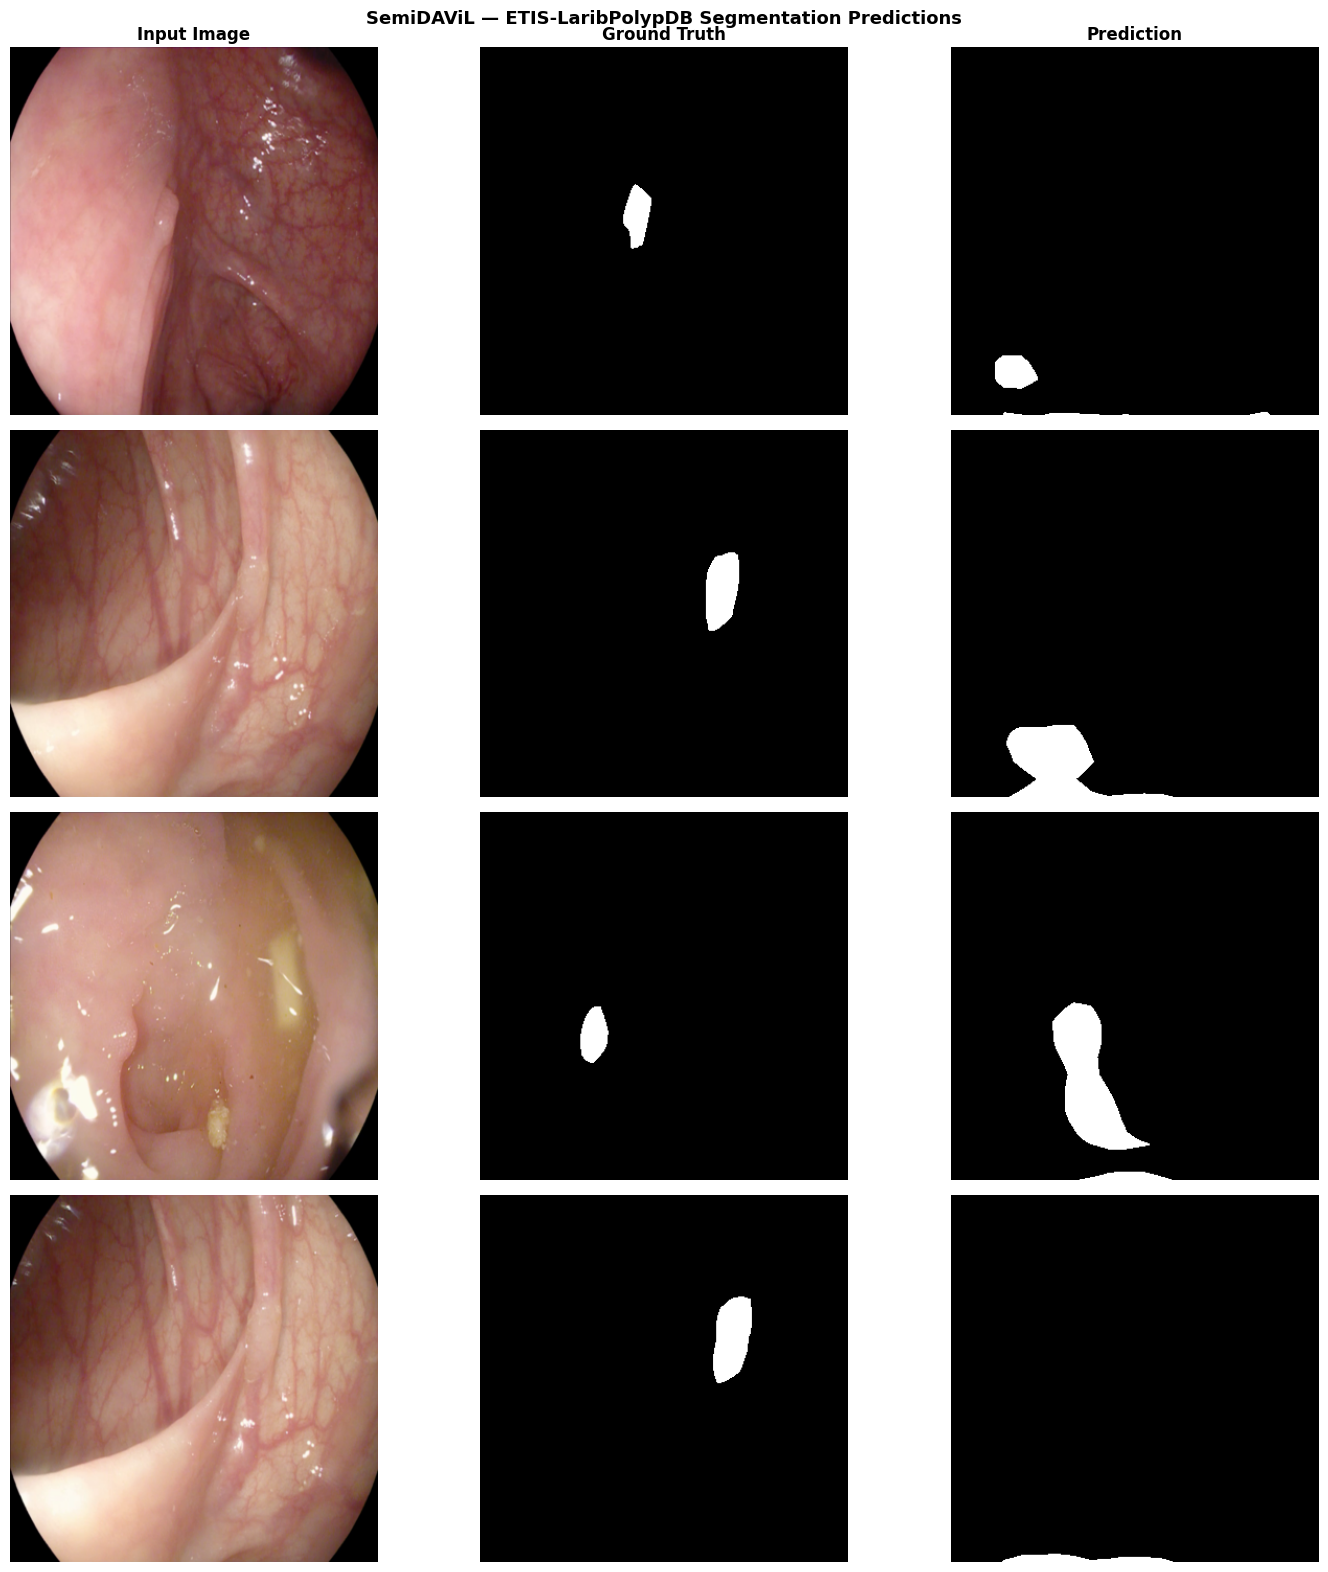

Done.


In [ ]:
# ========================================================
# CELL 19 — Rebuild segmentation test_loader, then visualize
# ========================================================
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# --- Rebuild the ETIS segmentation test loader from scratch ---
# (test_loader may have been overwritten by a lung cancer ImageFolder cell)
class PolypDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=352, augment=False):
        self.img_paths  = sorted(glob.glob(os.path.join(img_dir,  '*')))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, '*')))
        self.img_size   = img_size
        self.augment    = augment
        self.img_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
        ])
        self.mask_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img  = Image.open(self.img_paths[idx]).convert('RGB')
        mask = Image.open(self.mask_paths[idx]).convert('L')
        img  = self.img_transform(img)
        mask = self.mask_transform(mask)
        mask = (mask > 0.5).float()
        return img, mask

seg_test_ds = PolypDataset(
    img_dir   = TEST_IMG_DIR,
    mask_dir  = TEST_MASK_DIR,
    img_size  = IMG_SIZE,
    augment   = False
)
seg_test_loader = DataLoader(seg_test_ds, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2)
print(f'Segmentation test set: {len(seg_test_ds)} images (ETIS-LaribPolypDB)')

# --- Collect predictions ---
model.student_dlg.eval()
model.student_decoder.eval()

def denorm_seg(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

seg_imgs_list, seg_masks_list, seg_preds_list = [], [], []

with torch.no_grad():
    for imgs, masks in seg_test_loader:
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        preds = model(imgs, text_feats, network='student')
        seg_imgs_list.append(imgs.cpu())
        seg_masks_list.append(masks.cpu())
        seg_preds_list.append(preds.cpu())
        if sum(x.shape[0] for x in seg_imgs_list) >= 4:
            break

seg_imgs  = torch.cat(seg_imgs_list,  dim=0)
seg_masks = torch.cat(seg_masks_list, dim=0)
seg_preds = torch.cat(seg_preds_list, dim=0)

# --- Plot ---
n_show  = min(4, seg_imgs.shape[0])
indices = random.sample(range(seg_imgs.shape[0]), n_show)

fig, axes = plt.subplots(n_show, 3, figsize=(15, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for row, idx in enumerate(indices):
    img      = denorm_seg(seg_imgs[idx])
    gt_mask  = seg_masks[idx].squeeze().numpy()
    pred_bin = (torch.sigmoid(seg_preds[idx]).squeeze().numpy() > 0.5).astype(float)

    axes[row, 0].imshow(img);             axes[row, 0].axis('off')
    axes[row, 1].imshow(gt_mask,  cmap='gray'); axes[row, 1].axis('off')
    axes[row, 2].imshow(pred_bin, cmap='gray'); axes[row, 2].axis('off')
    if row == 0:
        for col, title in enumerate(['Input Image', 'Ground Truth', 'Prediction']):
            axes[row, col].set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('SemiDAViL — ETIS-LaribPolypDB Segmentation Predictions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('segmentation_predictions.png', dpi=150)
plt.show()
print('Done.')

In [ ]:
# ========================================================
# CELL 20 — CARZero Classification Architecture
# ========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F


class BidirectionalNodeAttention(nn.Module):
    """Self-attention with local neighbourhood mask."""
    def __init__(self, embed_dim, num_heads=8):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm      = nn.LayerNorm(embed_dim)
        self.ffn       = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Linear(embed_dim * 2, embed_dim)
        )
        self.ffn_norm  = nn.LayerNorm(embed_dim)

    def _make_mask(self, seq_len, device):
        mask = torch.full((seq_len, seq_len), float('-inf'), device=device)
        for i in range(seq_len):
            mask[i, i] = 0.0
            if i > 0:           mask[i, i-1] = 0.0
            if i < seq_len - 1: mask[i, i+1] = 0.0
        return mask

    def forward(self, x):
        B, L, D  = x.shape
        bi_mask  = self._make_mask(L, x.device)
        attn_out, _ = self.attention(x, x, x, attn_mask=bi_mask)
        x = self.norm(x + attn_out)
        x = self.ffn_norm(x + self.ffn(x))
        return x


class CARZeroAlignment(nn.Module):
    """Cross-attention: visual features (Q) attend to CLIP text embeddings (K, V)."""
    def __init__(self, embed_dim, num_heads=8):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm       = nn.LayerNorm(embed_dim)

    def forward(self, visual_features, text_features):
        # visual_features: (B, 1, D) — pooled spatial token
        # text_features:   (B, C, D) — C class embeddings from CLIP
        aligned, attn_weights = self.cross_attn(
            query=visual_features,
            key=text_features,
            value=text_features
        )
        aligned = self.norm(visual_features + aligned)
        return aligned, attn_weights


class CustomBidirectionalCARZero(nn.Module):
    """
    CARZero classifier.
    vis_tokens (B,N,D)
      → BidirectionalNodeAttention
      → AvgPool  →  CARZeroAlignment with CLIP class text embeddings
      → Linear head  →  logits (B, C)
    """
    def __init__(self, feature_dim=512, num_classes=2):
        super().__init__()
        self.bidirectional = BidirectionalNodeAttention(feature_dim)
        self.carzero_align = CARZeroAlignment(feature_dim)
        self.classifier    = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, vis_tokens, text_class_embeds):
        """
        vis_tokens:        (B, N, D)
        text_class_embeds: (C, D)    — CLIP-encoded class descriptions
        returns logits:    (B, C)
        """
        B = vis_tokens.size(0)

        # spatial self-attention
        x        = self.bidirectional(vis_tokens)             # (B, N, D)

        # global pooling
        x_pooled = x.mean(dim=1, keepdim=True)               # (B, 1, D)

        # cross-attention alignment with class text embeddings
        text_exp = text_class_embeds.unsqueeze(0).expand(B, -1, -1)  # (B, C, D)
        aligned, _ = self.carzero_align(x_pooled, text_exp)           # (B, 1, D)
        aligned    = aligned.squeeze(1)                                # (B, D)

        # classify
        logits = self.classifier(aligned)                     # (B, C)
        return logits


print('CARZero classification architecture defined.')

CARZero classification architecture defined.


In [ ]:
# ========================================================
# CELL 21 — Train CARZero on Kvasir (Normal vs Polyp)
# ========================================================
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score

# --- encode class text embeddings with CLIP (frozen) ---
CLASS_TEXT_PROMPTS = {
    0: [
        "a normal healthy colon",
        "an endoscopic image of healthy colon mucosa",
        "a colonoscopy photo of normal colon tissue"
    ],
    1: [
        "a colonoscopy image showing a polyp",
        "an endoscopic photo of a colon polyp",
        "a photo of a polyp in the colon"
    ]
}

with torch.no_grad():
    class_embeds = []
    for cls_idx in sorted(CLASS_TEXT_PROMPTS.keys()):
        feats       = model.encode_text_prompts(CLASS_TEXT_PROMPTS[cls_idx], DEVICE)
        class_embed = feats.mean(dim=0)          # average 3 prompts → (512,)
        class_embeds.append(class_embed)
    text_class_embeds = torch.stack(class_embeds, dim=0).to(DEVICE)  # (2, 512)

print(f'Class text embeddings: {text_class_embeds.shape}')
print('Class 0 = Normal colon | Class 1 = Polyp')

# --- initialise classifier ---
clf_model     = CustomBidirectionalCARZero(feature_dim=512, num_classes=2).to(DEVICE)
clf_optimizer = optim.AdamW(clf_model.parameters(), lr=CLF_LR, weight_decay=1e-4)
clf_scheduler = optim.lr_scheduler.CosineAnnealingLR(clf_optimizer, T_max=CLF_EPOCHS)
clf_criterion = nn.CrossEntropyLoss()

# --- training loop ---
clf_history  = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_acc = 0.0

print(f'\nStarting CARZero training for {CLF_EPOCHS} epochs...\n')

for epoch in range(CLF_EPOCHS):

    # ---- TRAIN ----
    clf_model.train()
    model.student_dlg.eval()       # SemiDAViL stays frozen
    model.student_decoder.eval()

    train_correct, train_total, running_loss = 0, 0, 0.0

    for imgs, labels in tqdm(clf_train_loader, desc=f'CLF Epoch {epoch+1}/{CLF_EPOCHS}'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        clf_optimizer.zero_grad()

        with torch.no_grad():
            vis_tokens = model.extract_visual_tokens(imgs)   # (B, N, D)

        logits = clf_model(vis_tokens, text_class_embeds)    # (B, 2)
        loss   = clf_criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(clf_model.parameters(), max_norm=1.0)
        clf_optimizer.step()

        running_loss  += loss.item()
        preds          = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    clf_scheduler.step()
    train_acc = train_correct / train_total

    # ---- VALIDATE ----
    clf_model.eval()
    val_preds_all, val_labels_all = [], []

    with torch.no_grad():
        for imgs, labels in clf_val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            vis_tokens   = model.extract_visual_tokens(imgs)
            logits       = clf_model(vis_tokens, text_class_embeds)
            preds        = logits.argmax(dim=1)
            val_preds_all.extend(preds.cpu().numpy())
            val_labels_all.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels_all, val_preds_all)
    val_f1  = f1_score(val_labels_all, val_preds_all, average='macro', zero_division=0)

    clf_history['train_loss'].append(running_loss / len(clf_train_loader))
    clf_history['train_acc'].append(train_acc)
    clf_history['val_acc'].append(val_acc)
    clf_history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1:>2}/{CLF_EPOCHS} | "
          f"Loss: {running_loss/len(clf_train_loader):.4f} | "
          f"Train: {train_acc*100:.2f}% | "
          f"Val: {val_acc*100:.2f}% | "
          f"F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(clf_model.state_dict(), 'best_carzero_clf.pth')

print(f'\nBest Val Accuracy: {best_val_acc*100:.2f}%')

Class text embeddings: torch.Size([2, 512])
Class 0 = Normal colon | Class 1 = Polyp

Starting CARZero training for 20 epochs...



CLF Epoch 1/20:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch  1/20 | Loss: 0.6676 | Train: 59.16% | Val: 72.67% | F1: 0.6996


CLF Epoch 2/20:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch  2/20 | Loss: 0.4219 | Train: 81.83% | Val: 88.00% | F1: 0.8800


...

Epoch 18/20 | Loss: 0.0569 | Train: 98.69% | Val: 97.33% | F1: 0.9733


CLF Epoch 19/20:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 19/20 | Loss: 0.0558 | Train: 98.55% | Val: 97.33% | F1: 0.9733


CLF Epoch 20/20:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 20/20 | Loss: 0.0554 | Train: 98.84% | Val: 97.33% | F1: 0.9733

Best Val Accuracy: 97.33%


CARZero Test:   0%|          | 0/10 [00:00<?, ?it/s]


CARZERO — Kvasir Test Set Results
  Accuracy  : 98.00%
  Precision : 97.97%  (macro)
  Recall    : 98.03%  (macro)
  F1 Score  : 98.00%  (macro)


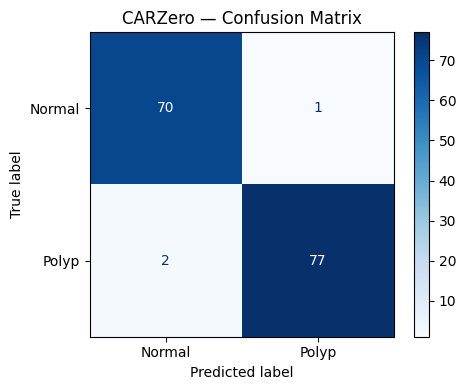

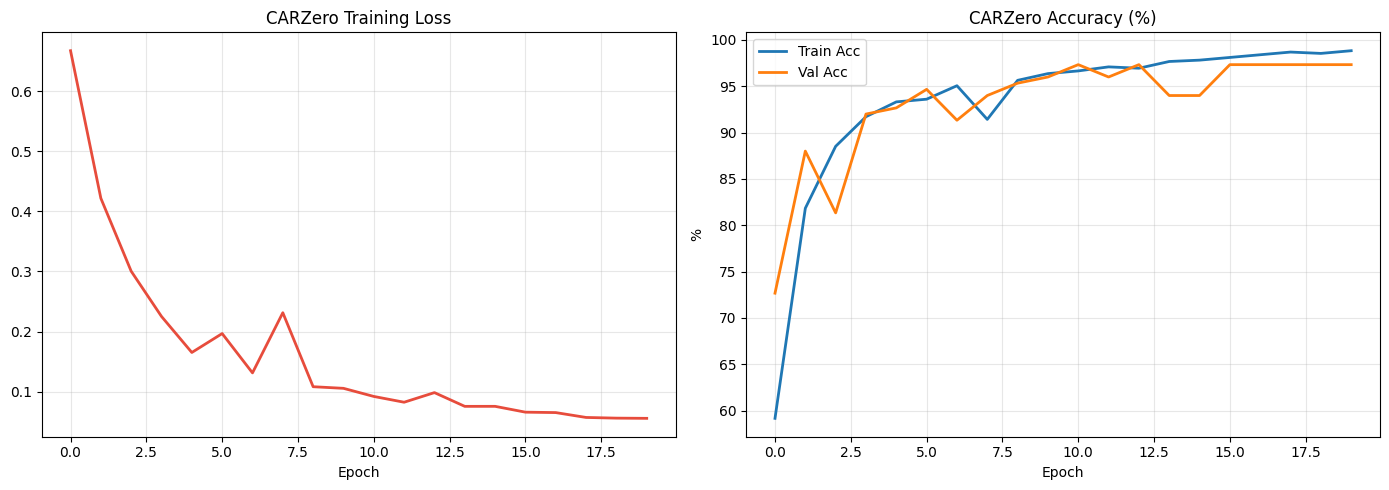

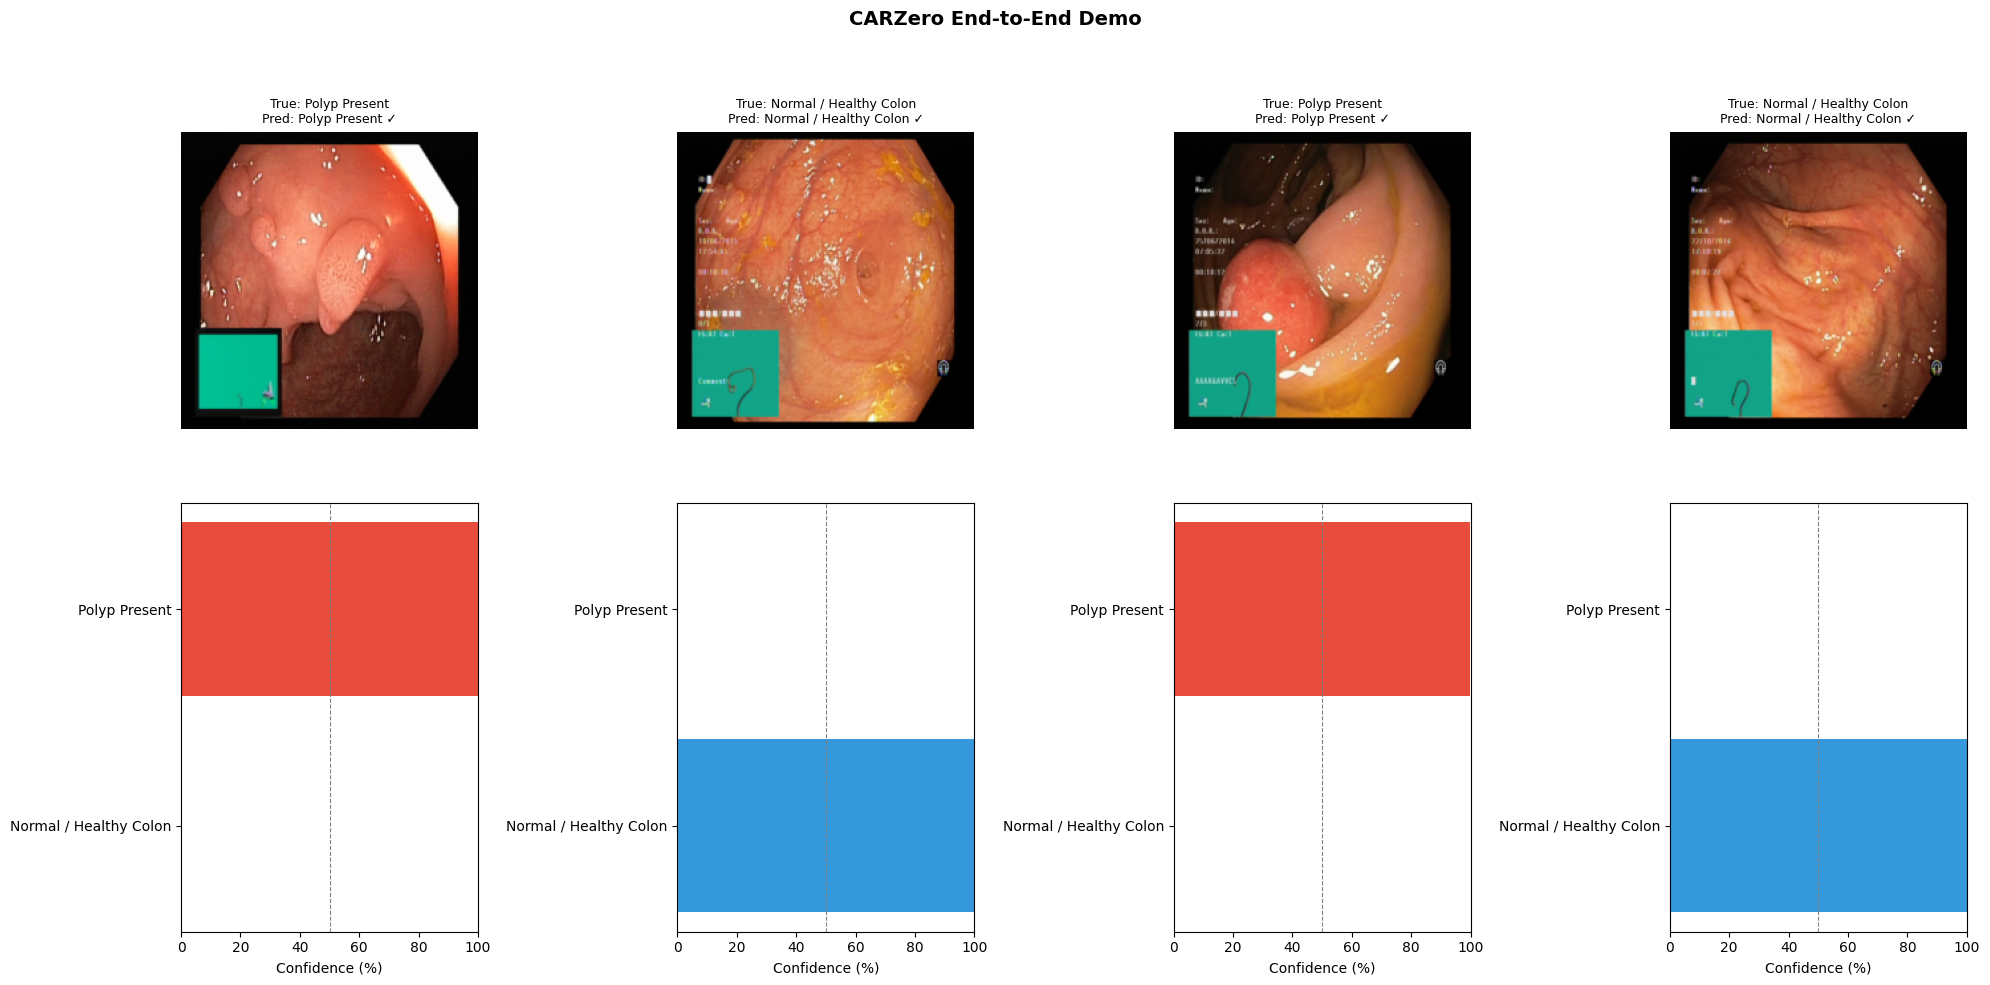

In [ ]:

import random
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)

# --- load best classifier ---
clf_model.load_state_dict(torch.load('best_carzero_clf.pth', map_location=DEVICE, weights_only=False))
clf_model.eval()
model.student_dlg.eval()
model.student_decoder.eval()

# --- test set evaluation ---
test_preds_all, test_labels_all = [], []

with torch.no_grad():
    for imgs, labels in tqdm(clf_test_loader, desc='CARZero Test'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        vis_tokens   = model.extract_visual_tokens(imgs)
        logits       = clf_model(vis_tokens, text_class_embeds)
        preds        = logits.argmax(dim=1)
        test_preds_all.extend(preds.cpu().numpy())
        test_labels_all.extend(labels.cpu().numpy())

acc  = accuracy_score(test_labels_all,  test_preds_all)
prec = precision_score(test_labels_all, test_preds_all, average='macro', zero_division=0)
rec  = recall_score(test_labels_all,    test_preds_all, average='macro', zero_division=0)
f1   = f1_score(test_labels_all,        test_preds_all, average='macro', zero_division=0)

print('\n' + '='*55)
print('CARZERO — Kvasir Test Set Results')
print('='*55)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%  (macro)')
print(f'  Recall    : {rec*100:.2f}%  (macro)')
print(f'  F1 Score  : {f1*100:.2f}%  (macro)')
print('='*55)

# --- confusion matrix ---
cm  = confusion_matrix(test_labels_all, test_preds_all)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Polyp']).plot(ax=ax, cmap='Blues')
ax.set_title('CARZero — Confusion Matrix')
plt.tight_layout()
plt.savefig('carzero_confusion_matrix.png', dpi=150)
plt.show()

# --- training curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(clf_history['train_loss'], color='#e74c3c', linewidth=2)
axes[0].set_title('CARZero Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in clf_history['train_acc']], label='Train Acc', linewidth=2)
axes[1].plot([a*100 for a in clf_history['val_acc']],   label='Val Acc',   linewidth=2)
axes[1].set_title('CARZero Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('carzero_training_curves.png', dpi=150)
plt.show()

# --- qualitative demo: 4 samples ---
class_names = ['Normal / Healthy Colon', 'Polyp Present']

def denorm_clf(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

sample_ids = random.sample(range(len(clf_test_ds)), 4)
fig, axes  = plt.subplots(2, 4, figsize=(20, 10))

for col, sid in enumerate(sample_ids):
    img, true_label = clf_test_ds[sid]
    img_dev = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        vis_tokens = model.extract_visual_tokens(img_dev)
        logits     = clf_model(vis_tokens, text_class_embeds)
        probs      = F.softmax(logits, dim=1)[0]
        pred_idx   = logits.argmax(dim=1).item()

    correct = '✓' if pred_idx == true_label else '✗'

    # row 0: image
    axes[0, col].imshow(denorm_clf(img))
    axes[0, col].axis('off')
    axes[0, col].set_title(
        f'True: {class_names[true_label]}\n'
        f'Pred: {class_names[pred_idx]} {correct}',
        fontsize=9
    )

    # row 1: confidence bar
    axes[1, col].barh(class_names,
                      [probs[0].item()*100, probs[1].item()*100],
                      color=['#3498db', '#e74c3c'])
    axes[1, col].set_xlim(0, 100)
    axes[1, col].set_xlabel('Confidence (%)')
    axes[1, col].axvline(50, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('CARZero End-to-End Demo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('carzero_demo.png', dpi=150)
plt.show()

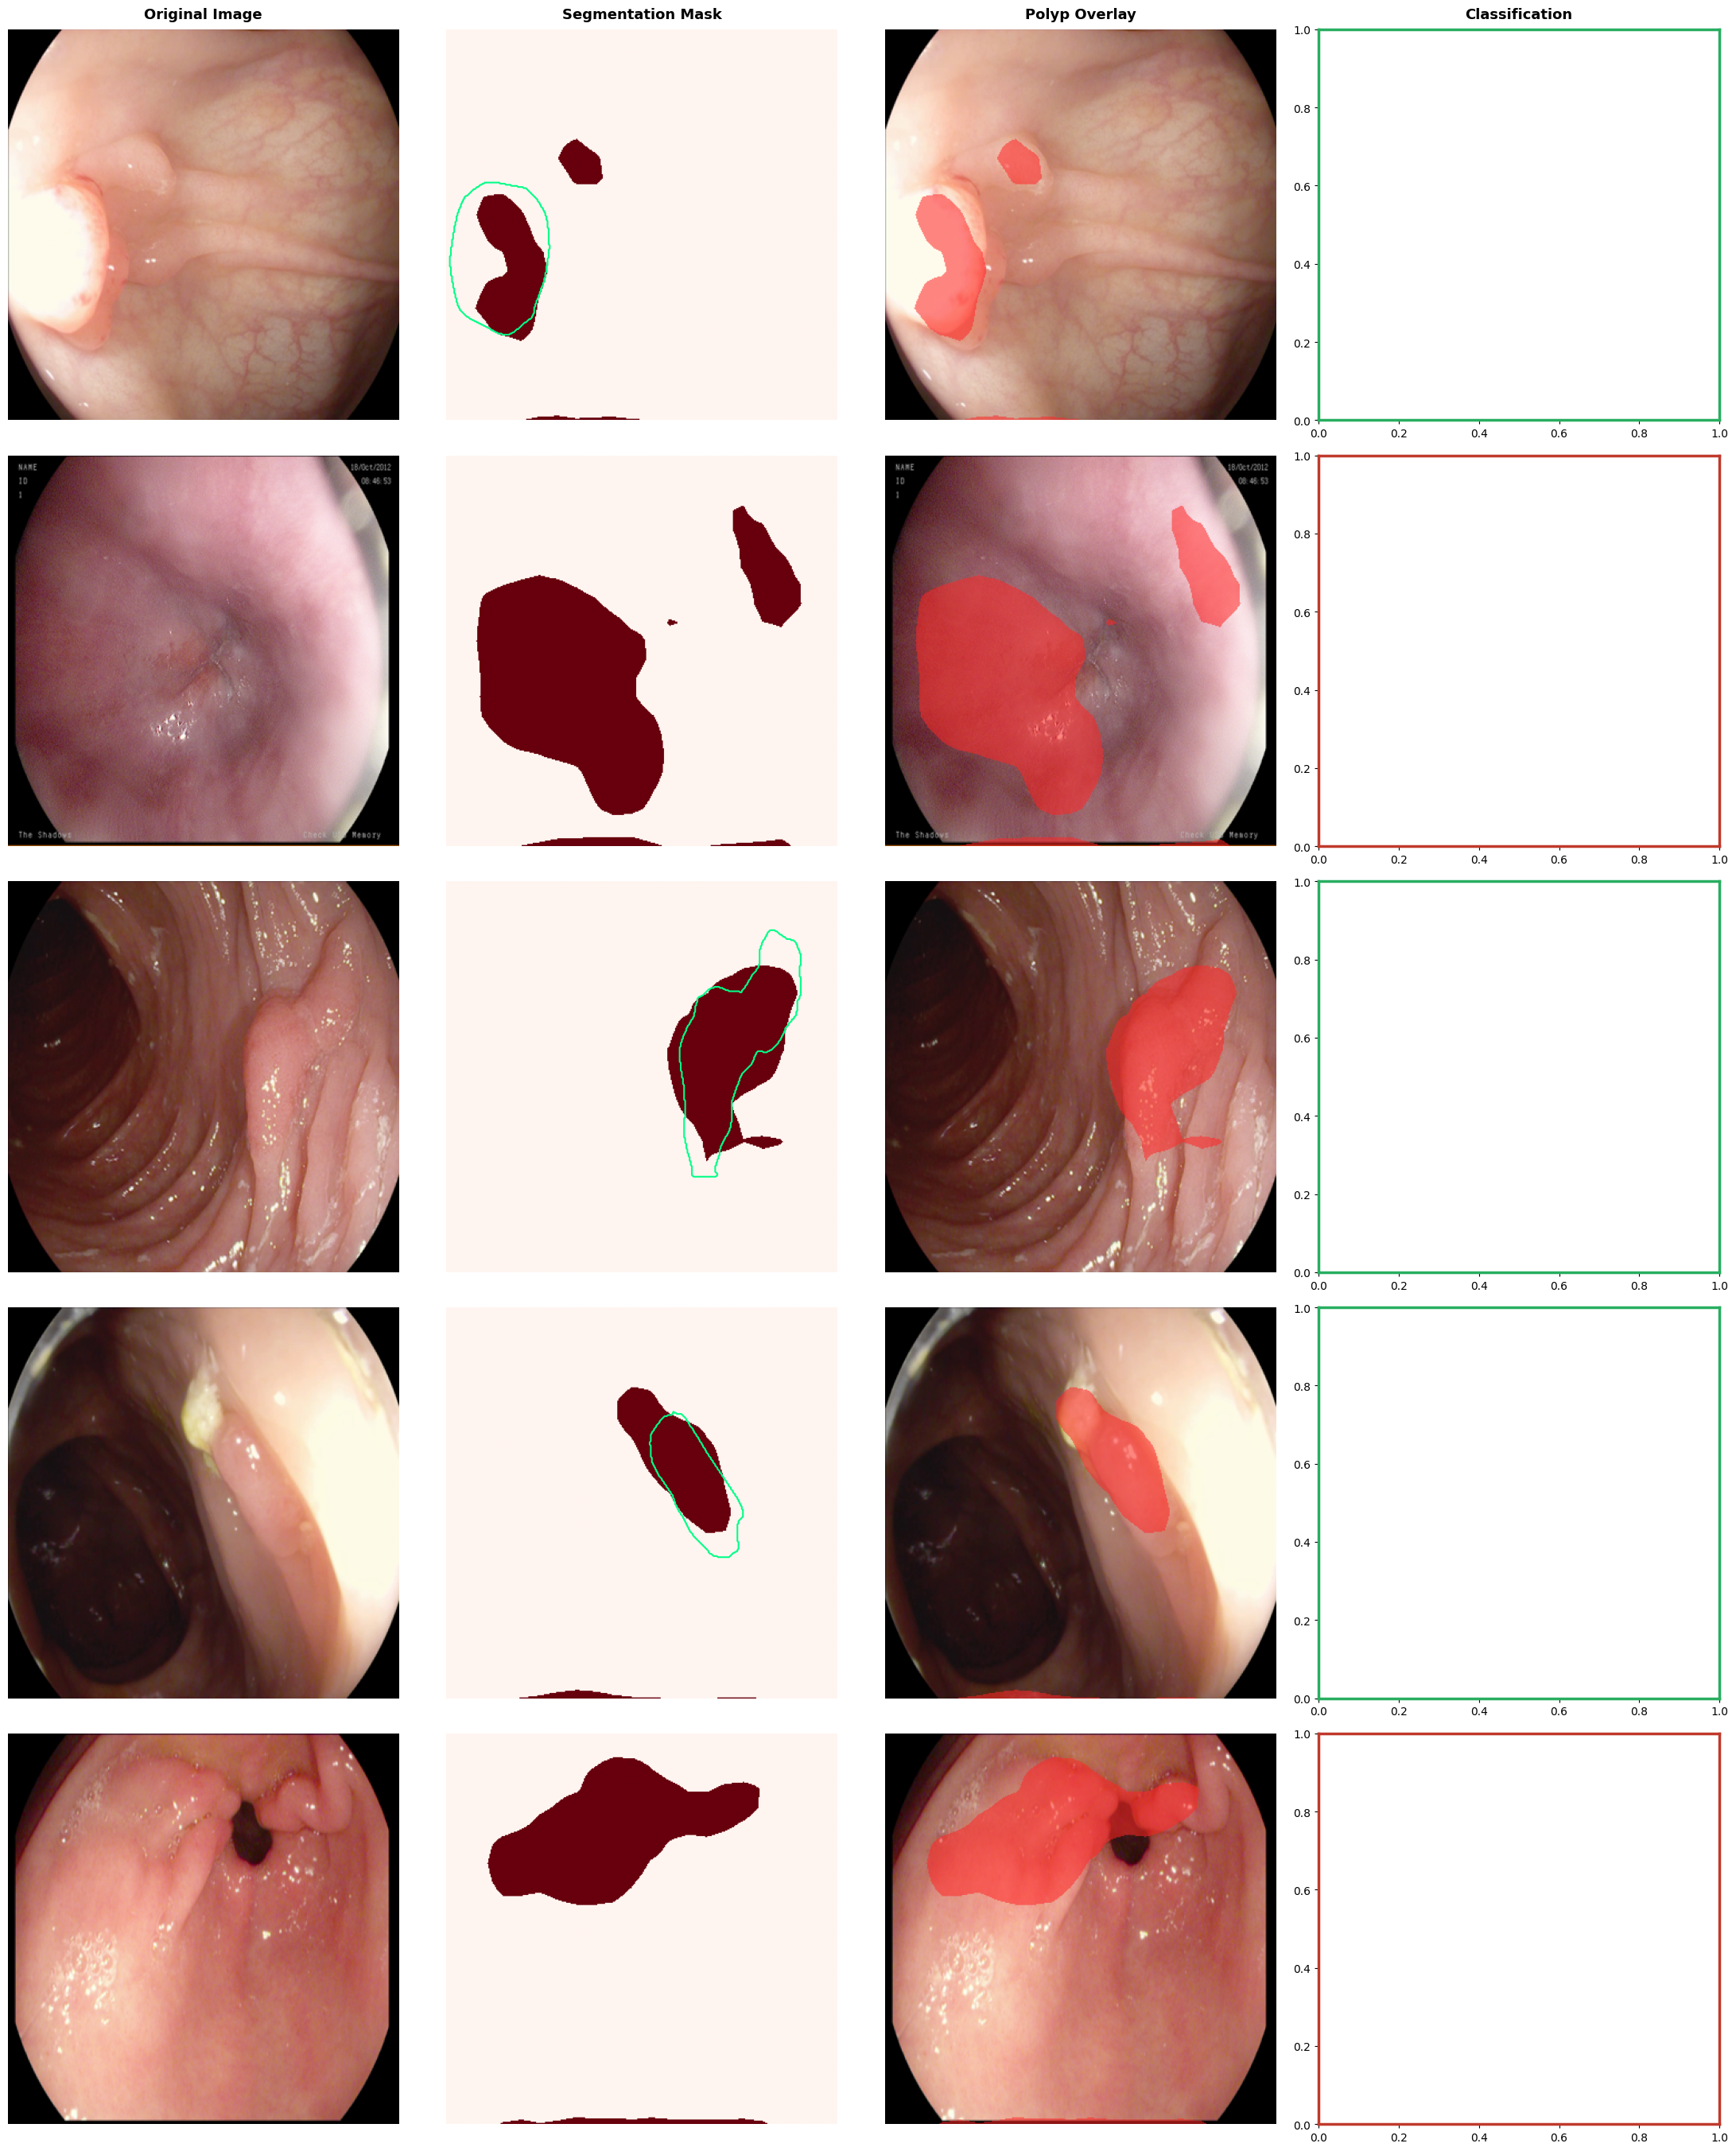

In [ ]:

import random, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as T

# --- helpers ---
def denorm(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (img_tensor.cpu() * std + mean).clamp(0,1).permute(1,2,0).numpy()

seg_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

clf_transform = T.Compose([
    T.Resize((CLF_IMG_SIZE, CLF_IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Pool A: ETIS polyp images (true label=1, have ground truth masks)
etis_imgs  = sorted(glob.glob(os.path.join(TEST_IMG_DIR,  '*')))
etis_masks = sorted(glob.glob(os.path.join(TEST_MASK_DIR, '*')))
etis_pool  = list(zip(etis_imgs, etis_masks))

# Pool B: Kvasir normal images (true label=0, no seg mask)
normal_pool = []
for folder in ['normal-cecum', 'normal-pylorus', 'normal-z-line']:
    fp = os.path.join(KVASIR_ROOT, folder)
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        normal_pool += glob.glob(os.path.join(fp, ext))

# Pick 3 polyp + 2 normal then shuffle
polyp_picks  = random.sample(etis_pool,   min(3, len(etis_pool)))
normal_picks = random.sample(normal_pool, min(2, len(normal_pool)))

# unified list: (img_path, mask_path_or_None, true_label)
samples = (
    [(p[0], p[1], 1) for p in polyp_picks] +
    [(p,    None,  0) for p in normal_picks]
)
random.shuffle(samples)

# --- set models to eval ---
model.student_dlg.eval()
model.student_decoder.eval()
clf_model.eval()

class_names  = ['Normal / Healthy Colon', 'Polyp Present']

fig, axes = plt.subplots(5, 4, figsize=(22, 28))
col_titles = ['Original Image', 'Segmentation Mask', 'Polyp Overlay', 'Classification']
for c, t in enumerate(col_titles):
    axes[0, c].set_title(t, fontsize=13, fontweight='bold', pad=10)

for row, (img_path, mask_path, true_label) in enumerate(samples):

    # load image
    pil_img  = Image.open(img_path).convert('RGB')
    orig_np  = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    seg_tensor = seg_transform(pil_img).unsqueeze(0).to(DEVICE)
    clf_tensor = clf_transform(pil_img).unsqueeze(0).to(DEVICE)

    # Phase 1: segmentation
    with torch.no_grad():
        seg_logits = model(seg_tensor, text_feats, network='student')
        seg_prob   = torch.sigmoid(seg_logits).squeeze().cpu().numpy()
        seg_mask   = (seg_prob > 0.5).astype(np.float32)

    # Phase 2: classification
    with torch.no_grad():
        vis_tokens = model.extract_visual_tokens(clf_tensor)
        clf_logits = clf_model(vis_tokens, text_class_embeds)
        probs      = F.softmax(clf_logits, dim=1)[0].cpu().numpy()
        pred_label = int(clf_logits.argmax(dim=1).item())

    # ground truth mask (blank for normal)
    if mask_path is not None:
        gt_mask = np.array(
            Image.open(mask_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
        ) / 255.0
        gt_mask = (gt_mask > 0.5).astype(np.float32)
    else:
        gt_mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    # red overlay on predicted polyp region
    overlay = orig_np.copy()
    if seg_mask.max() > 0:
        overlay[seg_mask > 0.5] = (
            overlay[seg_mask > 0.5] * 0.45 +
            np.array([1.0, 0.15, 0.15]) * 0.55
        )

    correct_sym = '✓' if pred_label == true_label else '✗'
    border_col  = '#27ae60' if pred_label == true_label else '#c0392b'

    # COL 0: original
    axes[row, 0].imshow(orig_np)
    axes[row, 0].axis('off')
    axes[row, 0].set_xlabel(
        f'True: {"Polyp" if true_label==1 else "Normal"}',
        fontsize=9, labelpad=4
    )

    # COL 1: seg mask + GT contour
    axes[row, 1].imshow(seg_mask, cmap='Reds', vmin=0, vmax=1)
    if mask_path is not None and gt_mask.max() > 0:
        axes[row, 1].contour(gt_mask, levels=[0.5],
                             colors=['#00ff88'], linewidths=1.5)
    axes[row, 1].axis('off')
    axes[row, 1].set_xlabel('Pred mask (red) | GT contour (green)',
                             fontsize=8, labelpad=4)

    # COL 2: overlay
    axes[row, 2].imshow(overlay)
    axes[row, 2].axis('off')
    pct = 100.0 * seg_mask.sum() / (IMG_SIZE * IMG_SIZE)
    axes[row, 2].set_xlabel(f'Polyp area: {pct:.1f}% of frame',
                             fontsize=9, labelpad=4)


    # coloured border: green=correct, red=wrong
    for c in range(4):
        for spine in axes[row, c].spines.values():
            spine.set_edgecolor(border_col)
            spine.set_linewidth(2.5)

# legend

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('end_to_end_demo.png', dpi=150, bbox_inches='tight')
plt.show()

Training and evaluating all architectures

CNN Baseline...
SemiDAViL + Single Attention...
SemiDAViL + Bidirectional Attention (no CARZero align)
SemiDAViL + CARZero + Bidirectional


Model                                        Accuracy  Precision   Recall       F1
CNN Baseline                                   88.67%     88.62%   88.67%   88.64%
SemiDAViL + Single Attn                        95.33%     95.36%   95.28%   95.32%
SemiDAViL + Bi Attn                            85.33%     89.11%   84.51%   84.72%
SemiDAViL + CARZero + Bidirectional            98.00%     97.97%   98.03%   98.00%




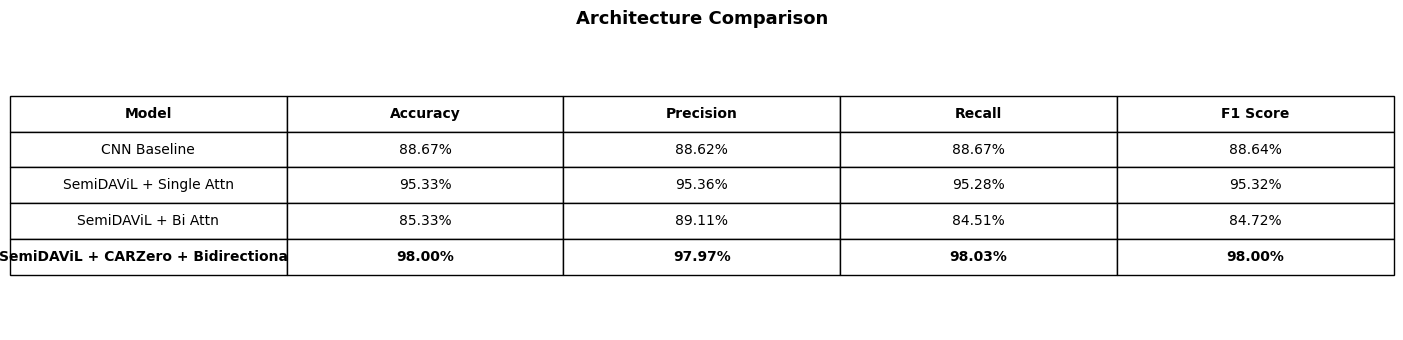

In [ ]:
print('Training and evaluating all architectures\n')

print('CNN Baseline...')
cnn = quick_train(CNNBaseline(), use_clip_tokens=False, epochs=10, lr=1e-3)
r_cnn = evaluate(cnn, use_clip_tokens=False)

print('SemiDAViL + Single Attention...')
single = quick_train(SingleAttentionCLF(), use_clip_tokens=True, epochs=10, lr=1e-3)
r_single = evaluate(single)

print('SemiDAViL + Bidirectional Attention (no CARZero align)')
class BidirectionalNoCARZero(nn.Module):
    def __init__(self, feature_dim=512, num_classes=2):
        super().__init__()
        self.attn = nn.MultiheadAttention(feature_dim, num_heads=8, batch_first=True)
        self.norm = nn.LayerNorm(feature_dim)
        self.ffn  = nn.Sequential(nn.Linear(feature_dim, feature_dim*2),
                                   nn.GELU(), nn.Linear(feature_dim*2, feature_dim))
        self.ffn_norm   = nn.LayerNorm(feature_dim)
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self._mask_cache = {}

    def _make_mask(self, L, device):
        if L not in self._mask_cache:
            mask = torch.full((L, L), float('-inf'), device=device)
            for i in range(L):
                mask[i, i] = 0.0
                if i > 0:       mask[i, i-1] = 0.0
                if i < L-1:     mask[i, i+1] = 0.0
            self._mask_cache[L] = mask
        return self._mask_cache[L]

    def forward(self, vis_tokens, *args):
        B, L, D = vis_tokens.shape
        mask = self._make_mask(L, vis_tokens.device)
        x, _ = self.attn(vis_tokens, vis_tokens, vis_tokens, attn_mask=mask)
        x = self.ffn_norm(self.norm(vis_tokens + x) + self.ffn(self.norm(vis_tokens + x)))
        return self.classifier(x.mean(dim=1))

bi_no_carzero = quick_train(BidirectionalNoCARZero(), use_clip_tokens=True, epochs=10, lr=1e-3)
r_bi = evaluate(bi_no_carzero)

print('SemiDAViL + CARZero + Bidirectional')
# use the already trained clf_model loaded from best_carzero_clf.pth
clf_model.load_state_dict(torch.load('best_carzero_clf.pth',
                                      map_location=DEVICE, weights_only=False))
r_ours = evaluate(clf_model)



arch_names = [
    'CNN Baseline',
    'SemiDAViL + Single Attn',
    'SemiDAViL + Bi Attn',
    'SemiDAViL + CARZero + Bidirectional ',
]
all_results = [r_cnn, r_single, r_bi, r_ours]
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Simple, unformatted text printout
print("\n")
print(f"{'Model':<42} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
for name, r in zip(arch_names, all_results):
    marker = '  (OURS)' if 'Ours' in name else ''
    print(f"{name:<42} {r[0]:>9.2f}% {r[1]:>9.2f}% {r[2]:>7.2f}% {r[3]:>7.2f}%{marker}")
print("\n")




fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis('off')

table_data = []
for name, r in zip(arch_names, all_results):
    table_data.append([name] + [f'{v:.2f}%' for v in r])

tbl = ax.table(
    cellText=table_data,
    colLabels=['Model'] + metrics,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.0)

num_rows = len(arch_names)
num_cols = len(metrics) + 1

# Simple Black and White Styling
for j in range(num_cols):
    # Bold the header row
    tbl[0, j].set_text_props(fontweight='bold')

for i in range(num_rows):
    if i == num_rows - 1:
        for j in range(num_cols):
            tbl[i+1, j].set_text_props(fontweight='bold')

plt.title('Architecture Comparison', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('comparison_table.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()